# geohierarchy in 5 steps

A `GeoHierarchy` is a graph of spatial levels (county → tract → block) that
automatically fills in shared columns everywhere, using the right spatial
resampling in each direction. `propagate()` runs **automatically** after
`add_level`, `add_vector_data`, `add_raster_data`, and `set_aggregation` --
you never have to call it yourself. See `docs.md` for the full reference.


### 1. Load some nested geographies

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
from geohierarchy import GeoHierarchy, Sum, Mean

set_matplotlib_formats("jpeg")  # smaller than PNG; fine since these plots have no transparency

files = Path("../tests/test_files")
county = gpd.read_file(files / "county.gpkg")
tract = gpd.read_file(files / "tract.gpkg")
block = gpd.read_file(files / "block.gpkg")
streets = gpd.read_file(files / "accessibility_place.gpkg")

### 2. Build the hierarchy

`add_level` registers a layer, `id_col` names its unique id, `agg` says how
its columns aggregate upward, and `parent` wires it into the graph. Each
call already fills in every level it can -- `block` gets no
`population_total` of its own, but immediately picks one up by
disaggregating `tract`'s values. Levels that already have real data are
never overwritten.


In [2]:
gh = GeoHierarchy()

gh.add_level("county", county[["GEOID", "population_total", "geometry"]], id_col="GEOID", agg=Sum())
gh.add_level("tract", tract[["GEOID", "population_total", "geometry"]], id_col="GEOID", agg=Sum(), parent="county")
gh.add_level("block", block[["GEOID", "geometry"]], id_col="GEOID", parent="tract")

gh.levels["block"]["population_total"].sum(), gh.levels["county"]["population_total"].sum()


(4865033.000000001, 7335732)

### 3. Bring in outside data

`add_vector_data` injects columns from any GeoDataFrame into one level --
it doesn't join the hierarchy graph. Here we add an `accessibility` score
at the `tract` level, weighted by population; it's spread to every other
level as soon as the call returns.


In [3]:
gh.add_vector_data(
    streets[["accessibility", "population_total", "geometry"]],
    level="tract",
    columns="accessibility",
    agg=Mean(weight_column="population_total"),
)

gh.levels["county"]["accessibility"].describe()


statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",0.135362
"""std""",0.178235
"""min""",0.0
"""25%""",0.0
"""50%""",0.078109
"""75%""",0.234849
"""max""",0.542209


### 4. Read a level back out

<Axes: >

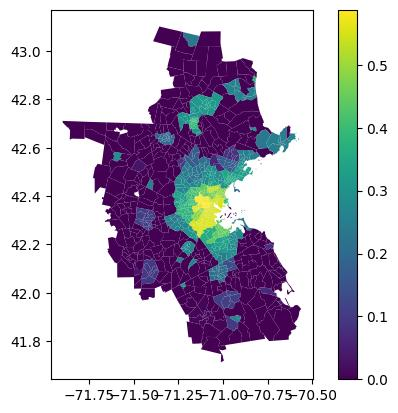

In [4]:
gh["tract"].plot(column="accessibility", legend=True)


## H3 and LineString layers, and synthetic rasters

Everything so far used polygon layers, but a level's geometry can be
anything -- H3 cells, linestrings, points. The examples below build on
the `tract` level from step 2.


### H3 cells as a core layer

`h3_cells(geometry, resolution)` vectorizes an H3 grid into ordinary
polygons, so it works with `add_level` exactly like any other layer.


In [5]:
from geohierarchy import h3_cells

one_tract = gh["tract"].iloc[[0]]
h3_grid = h3_cells(one_tract, resolution=9)
h3_grid["visits"] = 1  # one synthetic visit per cell, just to sum something

gh.add_level("h3", h3_grid, id_col="h3", agg=Sum(), parent="tract")

n_cells = len(h3_grid)
tract_total = gh.levels["tract"]["visits"].sum()
n_cells, tract_total

h3_grid["distance_to_centroid"] = h3_grid.geometry.centroid.distance(
    one_tract.geometry.iloc[0].centroid
)


/tmp/ipykernel_332634/1671461491.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_grid["distance_to_centroid"] = h3_grid.geometry.centroid.distance(
/tmp/ipykernel_332634/1671461491.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_grid["distance_to_centroid"] = h3_grid.geometry.centroid.distance(


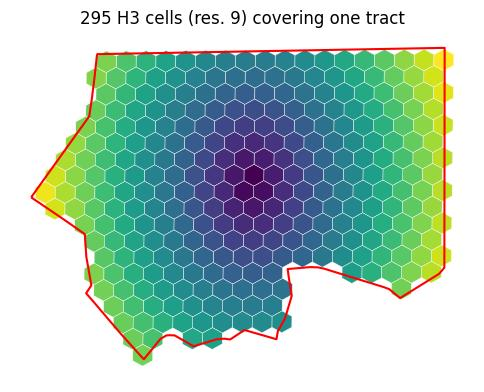

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
h3_grid.plot(column="distance_to_centroid", cmap="viridis", ax=ax, edgecolor="white", linewidth=0.3)
one_tract.boundary.plot(ax=ax, color="red", linewidth=1.5)
ax.set_title(f"{n_cells} H3 cells (res. 9) covering one tract")
ax.set_axis_off()

### A LineString layer (streets) as a child of a polygon layer

Streets clipped to that same tract, added as their own level -- `tract`'s
`population_total` immediately splits across them, length-weighted.


In [7]:
bbox = tuple(one_tract.to_crs(32619).total_bounds)
streets = gpd.read_file(files / "accessibility_streets.gpkg", bbox=bbox)

# osmid isn't a clean unique id in this OSM export (some rows hold a list
# of ids), so let add_level generate a plain positional id instead.
gh.add_level("streets", streets[["geometry"]], parent="tract")
gh.set_aggregation("population_total", Sum(geoweighted=True))

gh.levels["streets"]["population_total"].describe()

statistic,value
str,f64
"""count""",109.0
"""null_count""",0.0
"""mean""",71.018349
"""std""",80.863349
"""min""",44.11215
"""25%""",44.11215
"""50%""",44.11215
"""75%""",44.11215
"""max""",318.748513


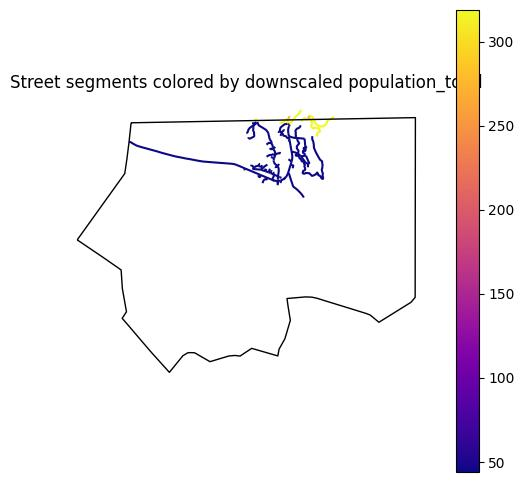

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
gh["streets"].plot(column="population_total", cmap="plasma", legend=True, ax=ax, linewidth=1.5)
one_tract.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_title("Street segments colored by downscaled population_total")
ax.set_axis_off()

### A synthetic raster

Any 2D array with an affine transform works -- here a made-up gradient
raster stands in for something like elevation or temperature.


In [9]:
import numpy as np
from affine import Affine

minx, miny, maxx, maxy = one_tract.total_bounds
size = 50
gradient = np.linspace(0, 100, size, dtype="float32")
synthetic = np.tile(gradient, (size, 1))  # increases west -> east
transform = Affine.translation(minx, maxy) * Affine.scale(
    (maxx - minx) / size, -(maxy - miny) / size
)

gh.add_raster_data(
    raster=synthetic,
    column="synthetic_index",
    level="tract",
    agg=Mean(),
    transform=transform,
    crs=4326,
)

gh.levels["tract"].filter(
    gh.levels["tract"]["_tract_GEOID"] == one_tract["_tract_GEOID"].iloc[0]
)["synthetic_index"][0]


53.66289138793945

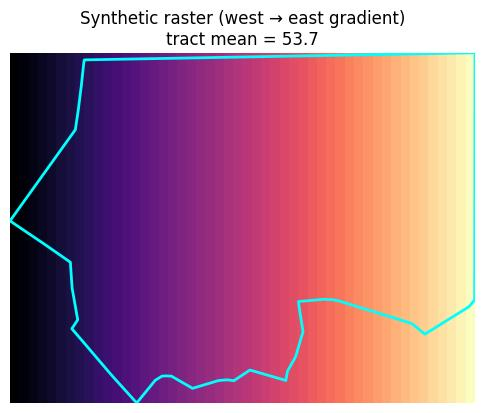

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(synthetic, cmap="magma", extent=(minx, maxx, miny, maxy))
one_tract.boundary.plot(ax=ax, color="cyan", linewidth=2)

tract_mean = gh.levels["tract"].filter(
    gh.levels["tract"]["_tract_GEOID"] == one_tract["_tract_GEOID"].iloc[0]
)["synthetic_index"][0]
ax.set_title(f"Synthetic raster (west \u2192 east gradient)\ntract mean = {tract_mean:.1f}")
ax.set_axis_off()